# **Imports**

In [1]:
import os
import yaml
import glob
import pandas as pd

from scipy.stats import ttest_rel
from scipy.stats import wilcoxon

# **Setup**

In [2]:
###################################
# Define Parameters & Settings
###################################

# output directory for deliverables...
output_dir = os.path.join(r'../assets/sgmap-net/classification')
if not os.path.isdir(output_dir):
    os.makedirs(output_dir)

# directory for experiments...
exp_dir = r'../experiments/sgmap-net/classification'

# **Loss Ablation**

## *Class Balance Strategies*

In [5]:
#############################################
# Class Balance Schemes for Loss Ablation
#############################################

# path to imbalance metrics
stats_path = r'../assets/data_eda/esv1p1_imbalance_metrics.csv'

# read into df
stats = pd.read_csv(stats_path)


##### inverse class frequency - PyTorch implementation for BCE pos_weight - (N-n_c) / n_c
N = len(glob.glob(r'../data/**/patches/*mask.tif'))
n_c = stats['Frequency (n)']
icf = (N-n_c) / n_c


##### IRLbl - just IRLbl
irlbl = stats['IRLbl']


##### ENS - Cui et al. (1/ENS)
raw_w_c = 1 / stats['N_eff']
sum_w_c = raw_w_c.sum()
normalize_factor = 7 / sum_w_c
final_w_c = raw_w_c * normalize_factor

In [6]:
icf

0      0.059684
1      0.649718
2      1.252905
3      1.843601
4      3.046178
5     20.615331
6    113.881481
Name: Frequency (n), dtype: float64

In [7]:
irlbl

0      1.000000
1      1.556802
2      2.126017
3      2.683443
4      3.818289
5     20.397909
6    108.411111
Name: IRLbl, dtype: float64

In [8]:
final_w_c

0    0.142326
1    0.158953
2    0.180176
3    0.202848
4    0.251584
5    1.007628
6    5.056486
Name: N_eff, dtype: float64

## *Loss Ablation Results*

In [70]:


loss_dir = r'../experiments/sgmap-net/classification/loss'


exp_dirs = glob.glob(f"{loss_dir}/**/*", recursive=False)

ablations = []
for d in exp_dirs:
    loss_name = os.path.dirname(d).split(os.sep)[-1]
    input_name = d.split(os.sep)[-1].split('_')[1]
    config_path = os.path.join(d, "config.yml")
    id_path = os.path.join(d, "id_global.csv")
    cd_path = os.path.join(d, "cd_global.csv")

    pos_weight = pd.NA
    if 'pos_weight' in loss_name:
        pos_weight = loss_name.split('-')[1]

    gamma = pd.NA
    alpha = pd.NA
    with open(config_path, "r") as f:
        c = yaml.safe_load(f)
        if 'gamma' in d or 'alpha' in d:
            gamma = c['loss']['classification']['params']['gamma']
            if 'gamma_' in d:
                pos_weight = loss_name.split('_')[1]
        if 'alpha' in d:
            alpha = c['loss']['classification']['params']['alpha']

    id = pd.read_csv(id_path)['macro_f1'].item()
    cd = pd.read_csv(cd_path)['macro_f1'].item()

    df = pd.DataFrame(
        columns=['input', 'pos_weight', 'gamma', 'alpha', 'f1_id', 'f1_cd'], 
        data=[[input_name, pos_weight, gamma, alpha, id, cd]]
        )
    ablations.append(df)

df = pd.concat(ablations)
df['delta'] = df['f1_id'] - df['f1_cd']
df['delta_rel'] = df['delta'] / df['f1_id'] * 100
df['total'] = df['f1_id'] + df['f1_cd']
df.fillna('-', inplace=True)
df.sort_values(['input', 'total'], ascending=[True, False], inplace=True)
output_path = os.path.join(output_dir, 'loss_ablation.csv')
df.to_csv(output_path, index=False)

df

,input,pos_weight,gamma,alpha,f1_id,f1_cd,delta,delta_rel,total
0,dem,-,0.5,0.5,0.680835,0.535058,0.145777,21.411500,1.215892
0,dem,-,3.0,-,0.666824,0.528058,0.138766,20.809985,1.194882
0,dem,-,0.5,0.25,0.662932,0.526220,0.136713,20.622428,1.189152
0,dem,ens,-,-,0.669437,0.508738,0.160699,24.005120,1.178176
0,dem,-,-,-,0.683138,0.492546,0.190591,27.899390,1.175684
0,dem,-,0.5,-,0.659143,0.516193,0.142950,21.687257,1.175335
0,dem,irlbl,0.5,-,0.665752,0.504897,0.160855,24.161396,1.170649
0,dem,-,1.0,-,0.673774,0.489090,0.184684,27.410419,1.162864
0,dem,-,0.5,0.75,0.663911,0.497343,0.166568,25.088953,1.161254
0,dem,icf,-,-,0.658020,0.488861,0.169159,25.707339,1.146880


In [75]:
df.groupby(['pos_weight', 'gamma', 'alpha'])['total'].mean().sort_values(ascending=False)

pos_weight  gamma  alpha
-           0.5    -        1.232564
            3.0    -        1.229897
            0.5    0.75     1.229644
                   0.5      1.229099
                   0.25     1.222793
            -      -        1.220123
            1.0    -        1.218705
            2.0    -        1.216248
            1.5    -        1.213931
irlbl       0.5    -        1.206862
            -      -        1.206665
ens         -      -        1.193714
icf         -      -        1.167348
Name: total, dtype: float64

# **Pre-trained vs. Random Initialization**

In [85]:

random_init_paths = glob.glob(r'../experiments/sgmap-net/classification/random_init/*')

ablations = []
for d in random_init_paths:
    input_name = os.path.split(d)[-1].split('_')[1]
    config_path = os.path.join(d, 'config.yml')
    id_path = os.path.join(d, 'id_global.csv')
    cd_path = os.path.join(d, 'cd_global.csv')

    with open(config_path, "r") as f:
        c = yaml.safe_load(f)
        pt = c['model']['sgmapnet_params']['pretrained']

    id = pd.read_csv(id_path)['macro_f1'].item()
    cd = pd.read_csv(cd_path)['macro_f1'].item()

    df = pd.DataFrame(columns=['input', 'pretrained', 'f1_id', 'f1_cd'], data=[[input_name, pt, id, cd]])
    ablations.append(df)

df = pd.concat(ablations)
df['delta'] = df['f1_id'] - df['f1_cd']
df['delta_rel'] = df['delta'] / df['f1_id'] * 100
df['total'] = df['f1_id'] + df['f1_cd']
df.sort_values(['input', 'total'], ascending=[True, False], inplace=True)
output_path = os.path.join(output_dir, 'pretrain_ablation.csv')
df.to_csv(output_path, index=False)
df

,input,pretrained,f1_id,f1_cd,delta,delta_rel,total
0,dem,True,0.659143,0.516193,0.142950,21.687257,1.175335
0,dem,False,0.650695,0.478100,0.172595,26.524698,1.128795
0,dem+s-ms,True,0.660962,0.601564,0.059398,8.986570,1.262527
0,dem+s-ms,False,0.662831,0.541501,0.121329,18.304710,1.204332
0,s-5,True,0.632307,0.601038,0.031269,4.945165,1.233345
0,s-5,False,0.646918,0.578546,0.068371,10.568794,1.225464
0,s-ms,True,0.644994,0.614055,0.030939,4.796722,1.259049
0,s-ms,False,0.643869,0.583712,0.060156,9.342959,1.227581


# **Single Feature Experiments**

## *Experiments Compilation*

In [3]:
single_dirs = glob.glob(r'../experiments/sgmap-net/classification/single*/*')

single_experiments = []
for idx, d in enumerate(single_dirs):
    input = os.path.split(d)[1].split('_')[1]
    exp_type = os.path.split(os.path.dirname(d))[1]
    df = pd.DataFrame({'input': input, 'exp_type': exp_type}, index=[0])
    if not os.path.isfile(os.path.join(d, 'id_global.csv')):
        continue
    id = pd.read_csv(os.path.join(d, 'id_global.csv'))
    cd = pd.read_csv(os.path.join(d, 'cd_global.csv'))
    df = pd.merge(left=df, right=id, suffixes=['', '_id'], left_index=True, right_index=True)
    df = pd.merge(left=df, right=cd, suffixes=['', '_cd'], left_index=True, right_index=True)
    single_experiments.append(df)

df = pd.concat(single_experiments)
df.sort_values(['input', 'exp_type'], ascending=True, inplace=True)
df.to_csv(r'../assets/sgmap-net/classification/single_compiled.csv', index=False)
df.head(6)

,input,exp_type,macro_precision,macro_recall,macro_f1,auroc,macro_map,micro_accuracy,macro_precision_cd,macro_recall_cd,macro_f1_cd,auroc_cd,macro_map_cd,micro_accuracy_cd
0,dem,single,0.666063,0.718795,0.686596,0.902980,0.735715,0.877139,0.474363,0.584874,0.507905,0.752566,0.564802,0.837240
0,dem,single_sa,0.646813,0.721616,0.674106,0.907855,0.730454,0.880208,0.538553,0.562986,0.527797,0.732125,0.546838,0.851935
0,ep-101,single,0.609858,0.681747,0.639822,0.849224,0.682126,0.868490,0.467570,0.531070,0.476510,0.725126,0.504596,0.821615
0,ep-101,single_sa,0.614553,0.692448,0.647729,0.887061,0.688232,0.867839,0.543429,0.489062,0.494903,0.774904,0.544505,0.854539
0,ep-11,single,0.614465,0.688306,0.644369,0.881664,0.704484,0.868397,0.422965,0.409105,0.402776,0.659112,0.471214,0.826172
0,ep-11,single_sa,0.606206,0.699948,0.645609,0.890427,0.692811,0.865048,0.459715,0.395216,0.402086,0.692302,0.478255,0.831659


In [5]:
df['total'] = df['macro_f1'] + df['macro_f1_cd']
df.sort_values('total', ascending=False)

,input,exp_type,macro_precision,macro_recall,macro_f1,auroc,macro_map,micro_accuracy,macro_precision_cd,macro_recall_cd,macro_f1_cd,auroc_cd,macro_map_cd,micro_accuracy_cd,total
0,s-10,single,0.667051,0.698330,0.674017,0.888170,0.715918,0.877511,0.535962,0.695868,0.598633,0.765624,0.651179,0.860677,1.272649
0,s-5,single,0.643111,0.689120,0.655159,0.875486,0.690786,0.880394,0.549497,0.698659,0.598273,0.809109,0.635838,0.859840,1.253432
0,sds-11,single_sa,0.621069,0.707442,0.655897,0.872078,0.685713,0.857980,0.498781,0.722317,0.581883,0.821724,0.622037,0.838449,1.237780
0,s-5,single_sa,0.637188,0.689851,0.649294,0.889731,0.702957,0.872954,0.535345,0.699622,0.588072,0.825067,0.623866,0.853516,1.237366
0,s-10,single_sa,0.615912,0.733216,0.649122,0.881002,0.699768,0.862630,0.513513,0.699887,0.583348,0.819845,0.618527,0.840309,1.232470
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,plc-100,single_sa,0.482512,0.681880,0.553721,0.752838,0.548676,0.757999,0.370360,0.586852,0.432745,0.670379,0.397900,0.714472,0.986466
0,plc-200,single_sa,0.447199,0.737429,0.545589,0.688204,0.484302,0.707403,0.350253,0.659917,0.433255,0.617788,0.374492,0.649089,0.978844
0,nhd,single,0.418252,0.741138,0.520200,0.651449,0.480504,0.680060,0.346607,0.708158,0.436665,0.588923,0.374807,0.634580,0.956866
0,plc-200,single,0.423617,0.780642,0.523196,0.692924,0.488311,0.678478,0.342448,0.726191,0.430029,0.626325,0.381539,0.619048,0.953226


## *Comparison*

In [35]:

single_path = r'../assets/sgmap-net/classification/single_compiled.csv'

df_single = pd.read_csv(single_path)

id = df_single[['input', 'exp_type', 'macro_f1']].pivot(columns='exp_type', index='input', values='macro_f1')
id.rename(columns={'single': 'f1_id', 'single_sa': 'f1_id_sa'}, inplace=True)
id['delta_id'] = id['f1_id'] - id['f1_id_sa']
id['delta_rel_id'] = id['delta_id'] / id['f1_id'] * 100

cd = df_single[['input', 'exp_type', 'macro_f1_cd']].pivot(columns='exp_type', index='input', values='macro_f1_cd')
cd.rename(columns={'single': 'f1_cd', 'single_sa': 'f1_cd_sa'}, inplace=True)
cd['delta_cd'] = cd['f1_cd'] - cd['f1_cd_sa']
cd['delta_rel_cd'] = cd['delta_cd'] / cd['f1_cd'] * 100

df = pd.merge(left=id, right=cd, how='inner', on='input')
df.to_csv(r'../assets/sgmap-net/classification/single_f1_comparison.csv')

df.head()

exp_type,f1_id,f1_id_sa,delta_id,delta_rel_id,f1_cd,f1_cd_sa,delta_cd,delta_rel_cd
input,,,,,,,,
dem,0.686596,0.674106,0.012490,1.819053,0.507905,0.527797,-0.019892,-3.916439
ep-101,0.639822,0.647729,-0.007907,-1.235773,0.476510,0.494903,-0.018393,-3.860013
ep-11,0.644369,0.645609,-0.001240,-0.192408,0.402776,0.402086,0.000690,0.171427
ep-201,0.638959,0.634922,0.004037,0.631800,0.514089,0.472749,0.041340,8.041469
ep-21,0.639944,0.657561,-0.017617,-2.752946,0.402102,0.407587,-0.005486,-1.364209


In [37]:
#############################################
# Statistical Test if Self-Attention Helps
#############################################

# H0: no attention = self-attention
# HA: no attention < self-attention

##### In-domain...
print('In-domain...')
print('Paired t-test')
id_result = ttest_rel(df['f1_id'], df['f1_id_sa'], alternative="less")
print(id_result.statistic)
print(id_result.pvalue)

print('Wilcoxon...')
id_stat, id_p = wilcoxon(df['f1_id'], df['f1_id_sa'], alternative='less')
print(id_stat)
print(id_p)


##### Cross-domain...
print('\nCross-domain...')
print('Paired t-test')
cd_result = ttest_rel(df['f1_cd'], df['f1_cd_sa'], alternative="less")
print(cd_result.statistic)
print(cd_result.pvalue)

print('Wilcoxon...')
cd_stat, cd_p = wilcoxon(df['f1_cd'], df['f1_cd_sa'], alternative='less')
print(cd_stat)
print(cd_p)

In-domain...
Paired t-test
-0.3047908691415534
0.3811916997170969
Wilcoxon...
340.0
0.6600647745945025

Cross-domain...
Paired t-test
0.7382456568455873
0.7672846531703243
Wilcoxon...
384.0
0.8707472264068201


# **Multi-scale Feature Experiments**

## *Experiments Compilation*

In [6]:
ms_dirs = glob.glob(r'../experiments/sgmap-net/classification/multiscale*/*')

ms_experiments = []
for idx, d in enumerate(ms_dirs):
    input = os.path.split(d)[1].split('_')[1]
    exp_type = os.path.split(os.path.dirname(d))[1]
    df = pd.DataFrame({'input': input, 'exp_type': exp_type}, index=[0])
    id = pd.read_csv(os.path.join(d, 'id_global.csv'))
    cd = pd.read_csv(os.path.join(d, 'cd_global.csv'))
    df = pd.merge(left=df, right=id, suffixes=['', '_id'], left_index=True, right_index=True)
    df = pd.merge(left=df, right=cd, suffixes=['', '_cd'], left_index=True, right_index=True)
    ms_experiments.append(df)

df = pd.concat(ms_experiments)
df['input'] = df['input'].apply(lambda x: str(x).replace('-5', '-ms'))
df.sort_values(['input', 'exp_type'], ascending=True, inplace=True)
df.to_csv(r'../assets/sgmap-net/classification/multiscale_compiled.csv', index=False)
df.head(6)

,input,exp_type,macro_precision,macro_recall,macro_f1,auroc,macro_map,micro_accuracy,macro_precision_cd,macro_recall_cd,macro_f1_cd,auroc_cd,macro_map_cd,micro_accuracy_cd
0,ep-ms,multiscale_ca,0.564878,0.676851,0.611618,0.846565,0.654719,0.835565,0.495668,0.570864,0.524394,0.792255,0.536661,0.840123
0,ep-ms,multiscale_concat,0.540109,0.711324,0.605184,0.793966,0.609562,0.823661,0.471521,0.602091,0.522569,0.761197,0.511202,0.823289
0,ep-ms,multiscale_sa,0.630052,0.709049,0.656637,0.892674,0.711474,0.870350,0.424942,0.354528,0.372734,0.625795,0.444339,0.819289
0,ep-ms,multiscale_stack,0.644087,0.705643,0.669765,0.880303,0.709638,0.875279,0.457059,0.376771,0.393602,0.651380,0.465480,0.839844
0,plc-ms,multiscale_ca,0.475630,0.731694,0.541474,0.705170,0.568212,0.753627,0.399354,0.754916,0.472282,0.685125,0.419827,0.700893
0,plc-ms,multiscale_concat,0.460642,0.680368,0.540802,0.732838,0.538954,0.758371,0.370135,0.650197,0.455044,0.689465,0.434779,0.720331


## *Comparison*

In [7]:
ms_path = r'../assets/sgmap-net/classification/multiscale_compiled.csv'

df_ms = pd.read_csv(ms_path)

id = df_ms[['input', 'exp_type', 'macro_f1']].pivot(columns='exp_type', index='input', values='macro_f1')
id.rename(columns={'multiscale_stack': 'f1_id_stack', 'multiscale_sa': 'f1_id_sa', 'multiscale_concat': 'f1_id_concat', 'multiscale_ca': 'f1_id_ca'}, inplace=True)
id = id[['f1_id_stack', 'f1_id_sa', 'f1_id_concat', 'f1_id_ca']]

cd = df_ms[['input', 'exp_type', 'macro_f1_cd']].pivot(columns='exp_type', index='input', values='macro_f1_cd')
cd.rename(columns={'multiscale_stack': 'f1_cd_stack', 'multiscale_sa': 'f1_cd_sa', 'multiscale_concat': 'f1_cd_concat', 'multiscale_ca': 'f1_cd_ca'}, inplace=True)
cd = cd[['f1_cd_stack', 'f1_cd_sa', 'f1_cd_concat', 'f1_cd_ca']]

df = pd.merge(left=id, right=cd, how='inner', on='input')
df.to_csv(r'../assets/sgmap-net/classification/multiscale_f1_comparison.csv')

df.head()

exp_type,f1_id_stack,f1_id_sa,f1_id_concat,f1_id_ca,f1_cd_stack,f1_cd_sa,f1_cd_concat,f1_cd_ca
input,,,,,,,,
ep-ms,0.669765,0.656637,0.605184,0.611618,0.393602,0.372734,0.522569,0.524394
plc-ms,0.620096,0.622154,0.540802,0.541474,0.542030,0.548440,0.455044,0.472282
prc-ms,0.664299,0.660276,0.597618,0.599047,0.613630,0.590417,0.500238,0.504425
s-ms,0.658268,0.644445,0.602950,0.628413,0.596300,0.600552,0.568086,0.560052
sds-ms,0.638506,0.644158,0.583211,0.581333,0.592665,0.606179,0.534835,0.551461


In [27]:
#############################################
# Statistical Test if Self-Attention Helps
#############################################

# H0: no attention = self-attention
# HA: no attention < self-attention

##### In-domain -> stacking vs. stacking + self-attention
print('In-domain...')
print('Stacking < Self-attention')
print('Paired t-test')
id_result = ttest_rel(df['f1_id_stack'], df['f1_id_sa'], alternative="two-sided")
print(id_result.statistic)
print(id_result.pvalue)

print('Wilcoxon...')
id_stat, id_p = wilcoxon(df['f1_id_stack'], df['f1_id_sa'], alternative='two-sided')
print(id_stat)
print(id_p)


##### In-domain -> stacking vs. separate branches & concatenation
print('\nStacking < Concatenation')
print('Paired t-test')
id_result = ttest_rel(df['f1_id_stack'], df['f1_id_concat'], alternative="two-sided")
print(id_result.statistic)
print(id_result.pvalue)

print('Wilcoxon...')
id_stat, id_p = wilcoxon(df['f1_id_stack'], df['f1_id_concat'], alternative='two-sided')
print(id_stat)
print(id_p)


##### In-domain -> stacking vs. separate branches & cross-attention
print('\nStacking < Cross-attention')
print('Paired t-test')
id_result = ttest_rel(df['f1_id_stack'], df['f1_id_ca'], alternative="two-sided")
print(id_result.statistic)
print(id_result.pvalue)

print('Wilcoxon...')
id_stat, id_p = wilcoxon(df['f1_id_stack'], df['f1_id_ca'], alternative='two-sided')
print(id_stat)
print(id_p)

# ##### Cross-domain...
# print('\nCross-domain...')
# print('Paired t-test')
# cd_result = ttest_rel(df['f1_cd'], df['f1_cd_sa'], alternative="less")
# print(cd_result.statistic)
# print(cd_result.pvalue)

# print('Wilcoxon...')
# cd_stat, cd_p = wilcoxon(df['f1_cd'], df['f1_cd_sa'], alternative='less')
# print(cd_stat)
# print(cd_p)

In-domain...
Stacking < Self-attention
Paired t-test
1.1866278102653507
0.3010353994293491
Wilcoxon...
4.0
0.4375

Stacking < Concatenation
Paired t-test
14.502866231180851
0.00013142999557281773
Wilcoxon...
0.0
0.0625

Stacking < Cross-attention
Paired t-test
7.253048036704001
0.001918417674995637
Wilcoxon...
0.0
0.0625


# **Multimodal Experiments**

## *Experiments Compilation*

In [7]:
mm_dirs = glob.glob(r'../experiments/sgmap-net/classification/multimodal*/*')

mm_experiments = []
for idx, d in enumerate(mm_dirs):
    input = os.path.split(d)[1].split('_')[1:-2]
    input = '+'.join(input)
    exp_type = os.path.split(os.path.dirname(d))[1]
    df = pd.DataFrame({'input': input, 'exp_type': exp_type}, index=[0])
    id = pd.read_csv(os.path.join(d, 'id_global.csv'))
    cd = pd.read_csv(os.path.join(d, 'cd_global.csv'))
    df = pd.merge(left=df, right=id, suffixes=['', '_id'], left_index=True, right_index=True)
    df = pd.merge(left=df, right=cd, suffixes=['', '_cd'], left_index=True, right_index=True)
    mm_experiments.append(df)

df = pd.concat(mm_experiments)
df['input'] = df['input'].apply(lambda x: str(x).replace('-5', '-ms'))
df.sort_values(['input', 'exp_type'], ascending=True, inplace=True)
df.to_csv(r'../assets/sgmap-net/classification/multimodal_compiled.csv', index=False)
df.head(6)

,input,exp_type,macro_precision,macro_recall,macro_f1,auroc,macro_map,micro_accuracy,macro_precision_cd,macro_recall_cd,macro_f1_cd,auroc_cd,macro_map_cd,micro_accuracy_cd
0,dem+rgb,multimodal_ca,0.545577,0.640471,0.586353,0.821583,0.620737,0.834077,0.487927,0.623014,0.484227,0.721064,0.544699,0.745815
0,dem+rgb,multimodal_concat,0.561638,0.633918,0.594661,0.742215,0.602250,0.835193,0.527849,0.537375,0.524563,0.713398,0.534269,0.834728
0,dem+rgb,multimodal_sa,0.585049,0.757536,0.635652,0.872287,0.662004,0.841518,0.457439,0.543980,0.491887,0.654035,0.495877,0.817336
0,dem+rgb,multimodal_stack,0.597804,0.771703,0.641561,0.866343,0.665531,0.841518,0.451545,0.628456,0.518674,0.694276,0.516003,0.795945
0,dem+s-ms,multimodal_ca,0.601325,0.704186,0.632892,0.872683,0.669868,0.852307,0.490548,0.627990,0.543178,0.766463,0.574332,0.836124
0,dem+s-ms,multimodal_concat,0.574968,0.741684,0.634748,0.866992,0.675235,0.848307,0.485422,0.669713,0.557329,0.735093,0.597327,0.841146


## *Comparison*

In [8]:
ms_path = r'../assets/sgmap-net/classification/multimodal_compiled.csv'

df_ms = pd.read_csv(ms_path)

id = df_ms[['input', 'exp_type', 'macro_f1']].pivot(columns='exp_type', index='input', values='macro_f1')
id.rename(columns={'multimodal_stack': 'f1_id_stack', 'multimodal_sa': 'f1_id_sa', 'multimodal_concat': 'f1_id_concat', 'multimodal_ca': 'f1_id_ca'}, inplace=True)
id = id[['f1_id_stack', 'f1_id_sa', 'f1_id_concat', 'f1_id_ca']]

cd = df_ms[['input', 'exp_type', 'macro_f1_cd']].pivot(columns='exp_type', index='input', values='macro_f1_cd')
cd.rename(columns={'multimodal_stack': 'f1_cd_stack', 'multimodal_sa': 'f1_cd_sa', 'multimodal_concat': 'f1_cd_concat', 'multimodal_ca': 'f1_cd_ca'}, inplace=True)
cd = cd[['f1_cd_stack', 'f1_cd_sa', 'f1_cd_concat', 'f1_cd_ca']]

df = pd.merge(left=id, right=cd, how='inner', on='input')
# df.to_csv(r'../assets/sgmap-net/classification/multimodal_f1_comparison.csv')

df.sort_values('f1_id_stack', ascending=False)

exp_type,f1_id_stack,f1_id_sa,f1_id_concat,f1_id_ca,f1_cd_stack,f1_cd_sa,f1_cd_concat,f1_cd_ca
input,,,,,,,,
prc-ms+s-ms,0.674129,0.670921,0.636149,0.632443,0.612578,0.596656,0.544232,0.558600
dem+s-ms,0.670685,0.678532,0.634748,0.632892,0.591452,0.554339,0.557329,0.543178
ep-ms+prc-ms+s-ms,0.669797,0.689891,0.628470,0.604918,0.590905,0.563555,0.565660,0.575454
ep-ms+s-ms,0.662156,0.667206,0.605007,0.612901,0.595095,0.515122,0.535949,0.564292
rgb+dem+ep-ms+s-ms+sds-ms,0.655624,0.641484,0.511924,0.643695,0.547360,0.540297,0.403255,0.563869
ep-ms+prc-ms,0.654022,0.665343,0.607154,0.605158,0.496098,0.574997,0.546298,0.561993
rgb+dem+nhd+osm,0.649344,0.637752,0.582676,0.583704,0.483807,0.468171,0.466369,0.547782
ep-ms+s-ms+sds-ms,0.644385,0.665569,0.620573,0.606461,0.607874,0.600773,0.586808,0.602094
dem+rgb,0.641561,0.635652,0.594661,0.586353,0.518674,0.491887,0.524563,0.484227


# **Grad-CAM**

In [61]:
import geopandas as gpd
import os
import pandas as pd
from earthscape.constants import SG_MAPPING, SG_COLORS

import matplotlib.pyplot as plt
import rasterio

import numpy as np

from matplotlib.colors import ListedColormap

import yaml

In [ ]:

##### create evaluation set...
# get five random samples with each class...
areas_path = r'../data/esv1p1_areas.csv'
df_areas = pd.read_csv(areas_path)

df_areas['domain'] = df_areas['patch_id'].apply(lambda x: 'cd' if 'hv' in x or 'sonora' in x else 'id')


## *In-domain Test Set*

In [44]:
id_test_path = "../splits/esv1p1_splits/test_id.geojson"
df_id = gpd.read_file(id_test_path)

df = pd.merge(left=df_areas, right=df_id, how='right', on='patch_id')

# df_areas['domain'] = df_areas['patch_id'].apply(lambda x: 'cd' if 'hv' in x or 'sonora' in x else 'id')

df[df['domain'] == 'id'].sort_values('Qaf', ascending=False).head(10)

,patch_id,af1,Qal,Qaf,Qat,Qc,Qca,Qr,domain,geometry
1360,256_50_874,0.000000,0.501928,0.036513,0.0,0.315465,0.146094,0.000000,id,"POLYGON ((4671053.142 3519638.492, 4671053.142..."
2,256_50_14962,0.000000,0.504041,0.027421,0.0,0.028859,0.155735,0.283943,id,"POLYGON ((4735693.142 3479958.492, 4735693.142..."
151,256_50_14821,0.000000,0.132348,0.018322,0.0,0.011399,0.000000,0.837931,id,"POLYGON ((4735053.142 3479318.492, 4735053.142..."
829,256_50_13087,0.042137,0.519703,0.018283,0.0,0.006235,0.000000,0.413641,id,"POLYGON ((4726733.142 3534358.492, 4726733.142..."
1202,256_50_14126,0.000000,0.184349,0.016973,0.0,0.234841,0.060469,0.503368,id,"POLYGON ((4731853.142 3482518.492, 4731853.142..."
150,256_50_15127,0.000000,0.259692,0.016063,0.0,0.362750,0.000000,0.361496,id,"POLYGON ((4736333.142 3495958.492, 4736333.142..."
608,256_50_1774,0.000000,0.073562,0.009285,0.0,0.474042,0.000000,0.443111,id,"POLYGON ((4674893.142 3554198.492, 4674893.142..."
1412,256_50_2766,0.000000,0.351307,0.006503,0.0,0.352820,0.000000,0.289370,id,"POLYGON ((4679373.142 3559318.492, 4679373.142..."
173,256_50_340,0.000000,0.026170,0.000972,0.0,0.647463,0.014700,0.310695,id,"POLYGON ((4668493.142 3538838.492, 4668493.142..."
909,256_50_4414,0.000000,0.000000,0.000356,0.0,0.649824,0.000000,0.349819,id,"POLYGON ((4687053.142 3538838.492, 4687053.142..."


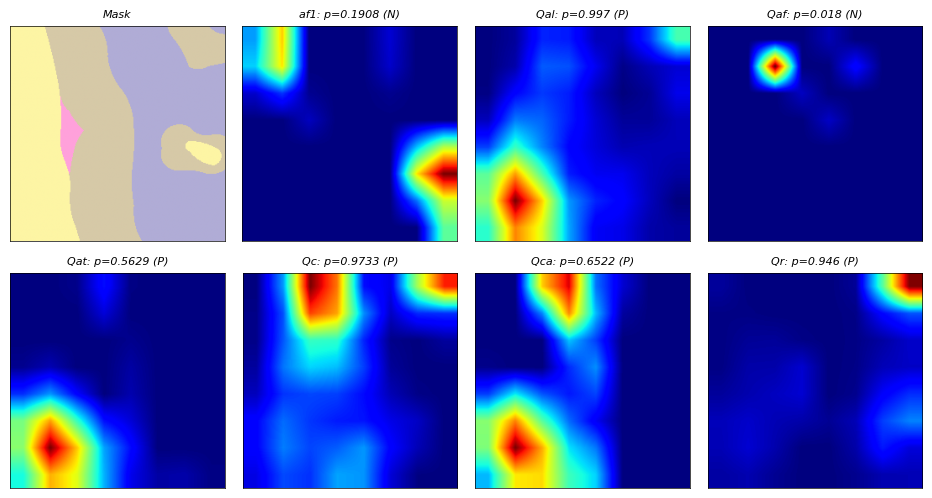

In [ ]:

inference_dir = r"../experiments/sgmap-net/classification/single/sgmap-net_s-10_20260802_183004/inference/20260807_142225"

patch_id = '256_50_15127'

mask_colors = [SG_COLORS[key] for key in SG_MAPPING.keys()]
mask_cmap = ListedColormap(mask_colors)


cams = np.load(os.path.join(inference_dir, 'gradcams', f"{patch_id}.npy"))


probs = pd.read_csv(os.path.join(inference_dir, 'predictions.csv'))
probs = probs.loc[probs['patch_id'] == patch_id]


with open(os.path.join(inference_dir, "config.yml")) as f:
    config = yaml.safe_load(f)
thresholds = config['eval']['thresholds']


fig, ax = plt.subplots(ncols=4, nrows=2, figsize=(12,6))
ax = ax.ravel()
plt.subplots_adjust(hspace=0.15, wspace=0)


with rasterio.open(f'../data/warren/patches/{patch_id}_mask.tif') as src:
    data = src.read(1)
    ax[0].imshow(data, vmin=1, vmax=7, cmap=mask_cmap)
    ax[0].set_title('Mask', fontsize=8, style='italic')

for idx, map_unit in enumerate(SG_MAPPING.keys(), start=1):
    ax[idx].imshow(cams[idx-1], cmap="jet", vmin=0, vmax=1)
    pred = 'P' if probs[map_unit].item() > thresholds[idx-1] else "N"
    title = f"{map_unit}: p={round(probs[map_unit].item(), 4)} ({pred})"
    ax[idx].set_title(title, fontsize=8, style='italic')

for a in ax:
    a.set_xticks([])
    a.set_yticks([])
    for spine in a.spines.values():
        spine.set_visible(True)
        spine.set_color("k")
        spine.set_linewidth(0.5)

plt.show()

## *Top 10 Largest*

In [84]:
df_areas[df_areas['domain'] == 'id'].nlargest(10, 'Qaf')
# df_areas[df_areas['domain'] == 'cd'].nlargest(10, 'Qaf')

,patch_id,af1,Qal,Qaf,Qat,Qc,Qca,Qr,domain
6390,256_50_2665,0.000000,0.112694,0.143698,0.000000,0.000000,0.000000,0.743608,id
6250,256_50_2525,0.000000,0.484229,0.138077,0.000000,0.000000,0.000000,0.377694,id
6251,256_50_2526,0.000000,0.435393,0.118383,0.003026,0.000000,0.000000,0.443198,id
6391,256_50_2666,0.000000,0.419942,0.118383,0.017580,0.000000,0.000000,0.444095,id
13193,256_50_9468,0.000000,0.616152,0.111993,0.000000,0.263147,0.000000,0.008708,id
13192,256_50_9467,0.000000,0.128593,0.111990,0.000000,0.706076,0.010883,0.042458,id
5582,256_50_1857,0.057188,0.294799,0.086154,0.108495,0.314879,0.138484,0.000000,id
13332,256_50_9607,0.000000,0.025084,0.085103,0.000000,0.639969,0.198210,0.051635,id
13333,256_50_9608,0.000000,0.388336,0.085103,0.000000,0.466035,0.000000,0.060526,id
6295,256_50_2570,0.000000,0.453574,0.070878,0.000000,0.068907,0.406640,0.000000,id


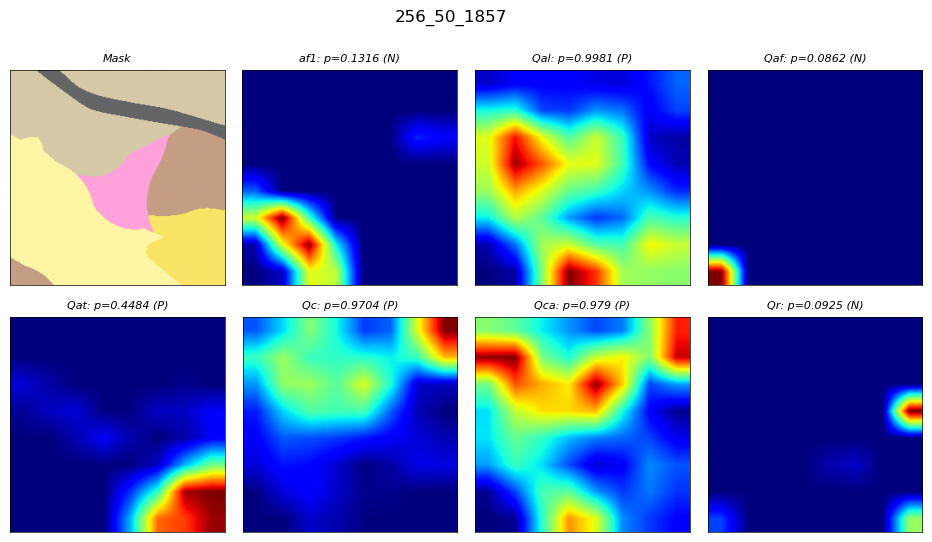

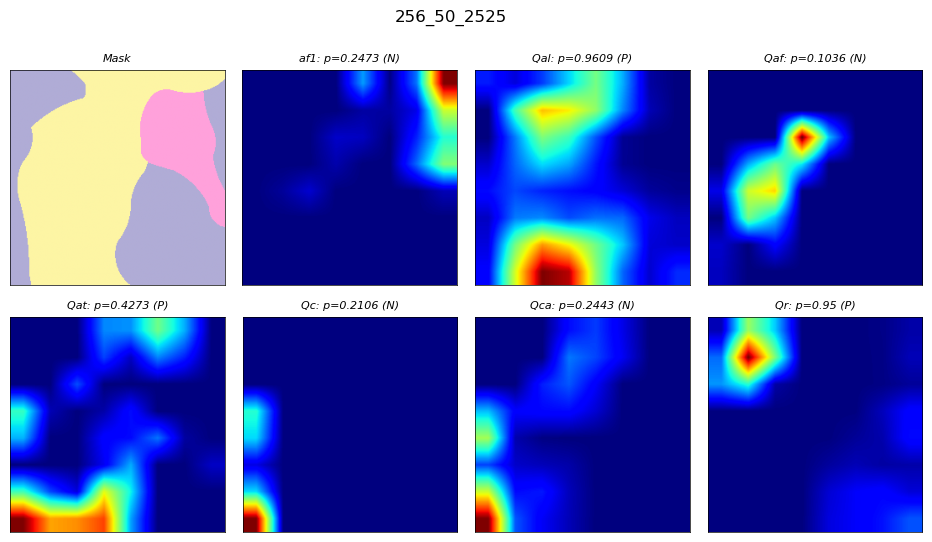

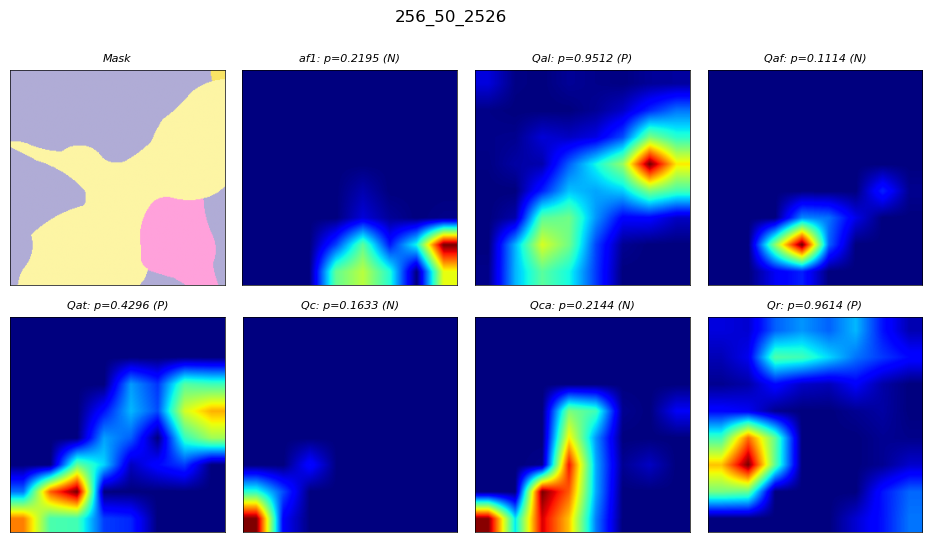

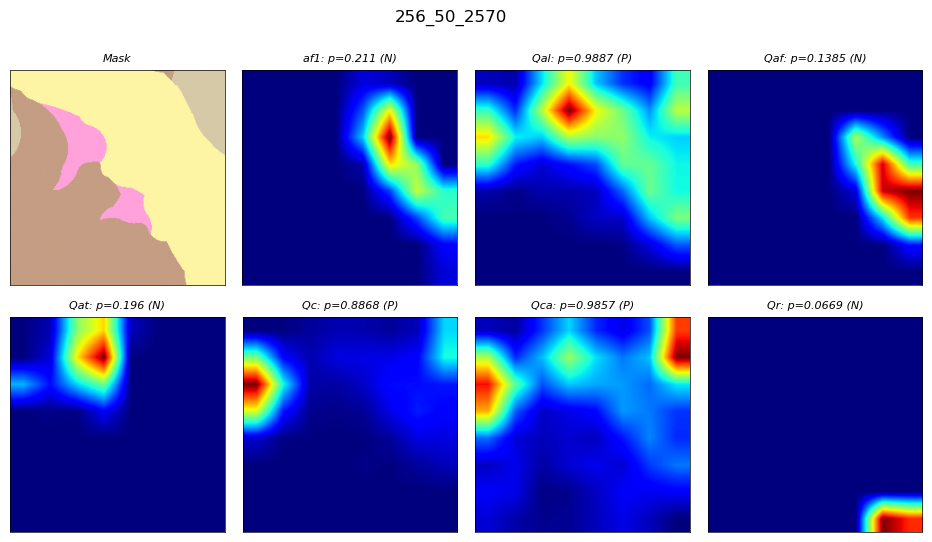

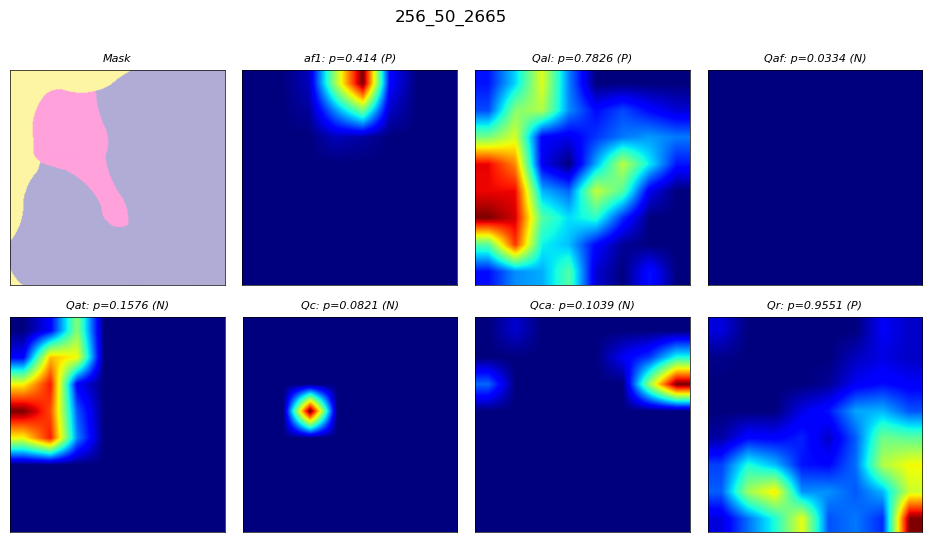

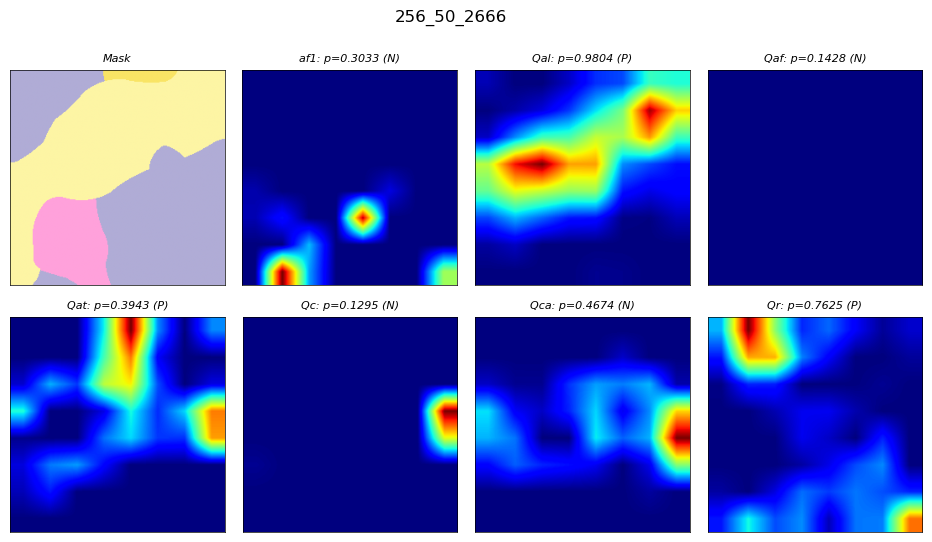

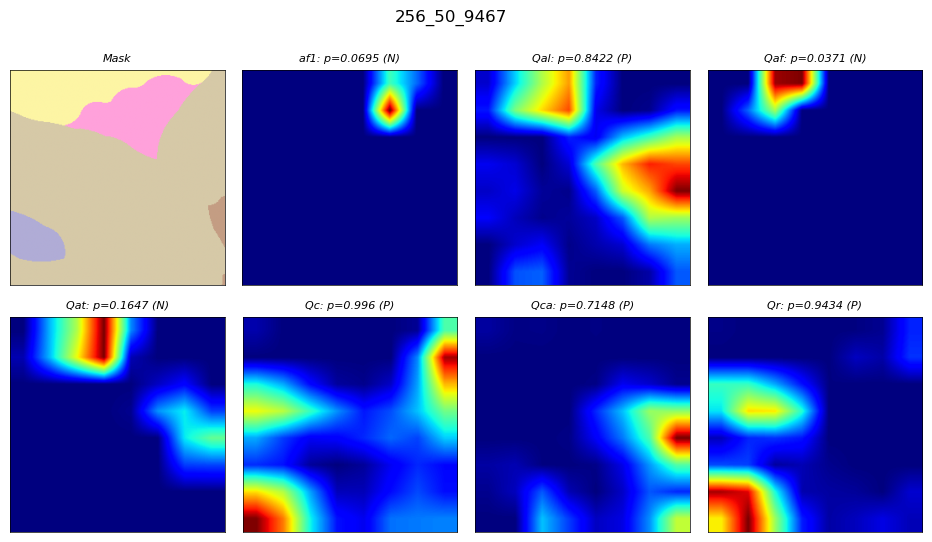

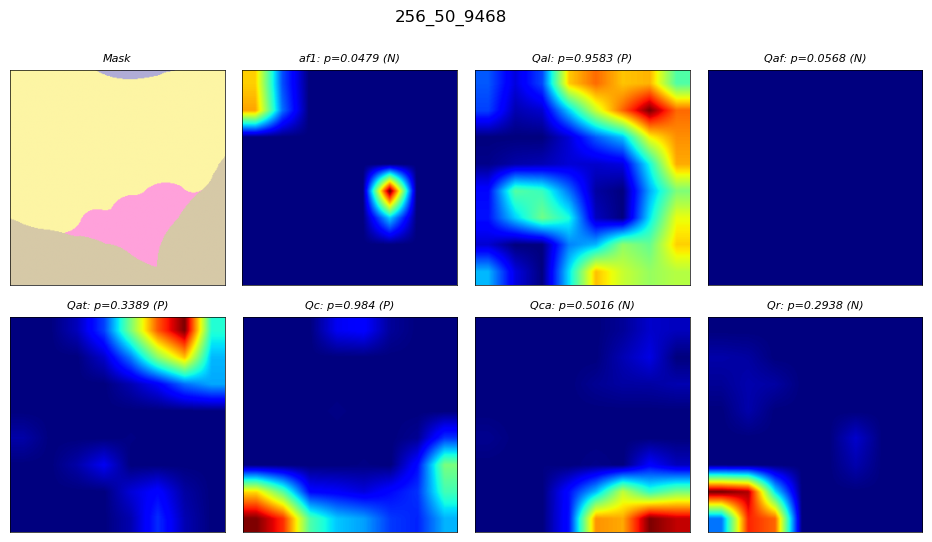

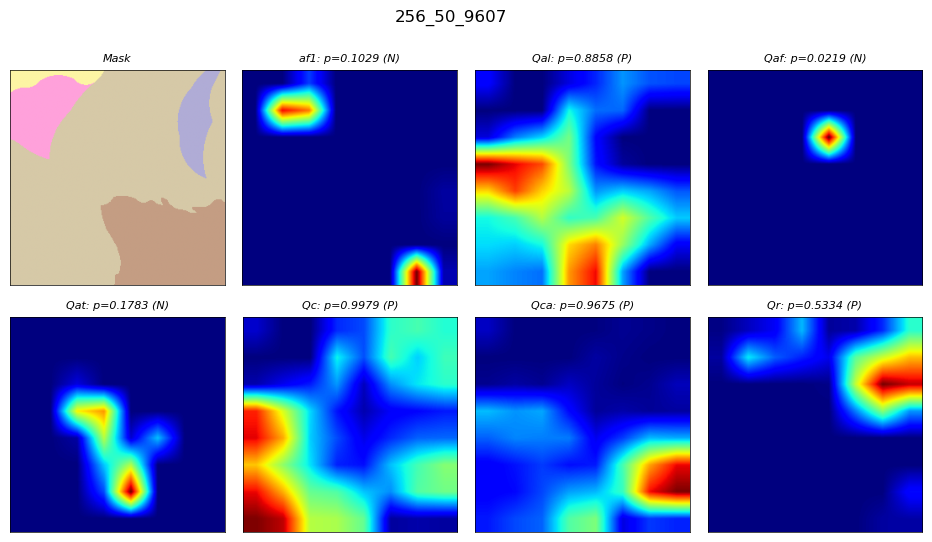

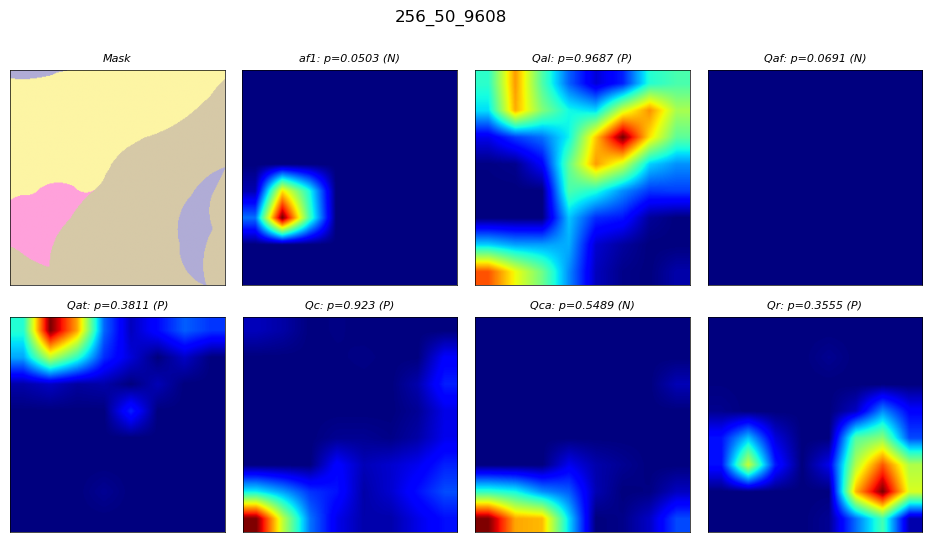

In [79]:
# In-domain...

inference_dir = r"E:\GitHub\earthscape\experiments\sgmap-net\classification\single\sgmap-net_s-10_20260802_183004\inference\20260807_154727"

# patch_id = '256_50_15127'

mask_colors = [SG_COLORS[key] for key in SG_MAPPING.keys()]
mask_cmap = ListedColormap(mask_colors)

for path in glob.glob(f"{inference_dir}/gradcams/*.npy"):
    patch_id = os.path.basename(path)
    patch_id = os.path.splitext(patch_id)[0]

    cams = np.load(path)


    probs = pd.read_csv(os.path.join(inference_dir, 'predictions.csv'))
    probs = probs.loc[probs['patch_id'] == patch_id]


    with open(os.path.join(inference_dir, "config.yml")) as f:
        config = yaml.safe_load(f)
    thresholds = config['eval']['thresholds']


    fig, ax = plt.subplots(ncols=4, nrows=2, figsize=(12,6))
    ax = ax.ravel()
    plt.subplots_adjust(hspace=0.15, wspace=0)


    with rasterio.open(f'../data/warren/patches/{patch_id}_mask.tif') as src:
        data = src.read(1)
        ax[0].imshow(data, vmin=1, vmax=7, cmap=mask_cmap)
        ax[0].set_title('Mask', fontsize=8, style='italic')

    for idx, map_unit in enumerate(SG_MAPPING.keys(), start=1):
        ax[idx].imshow(cams[idx-1], cmap="jet", vmin=0, vmax=1)
        pred = 'P' if probs[map_unit].item() > thresholds[idx-1] else "N"
        title = f"{map_unit}: p={round(probs[map_unit].item(), 4)} ({pred})"
        ax[idx].set_title(title, fontsize=8, style='italic')

    for a in ax:
        a.set_xticks([])
        a.set_yticks([])
        for spine in a.spines.values():
            spine.set_visible(True)
            spine.set_color("k")
            spine.set_linewidth(0.5)

    plt.suptitle(patch_id)
    plt.show()

    # break

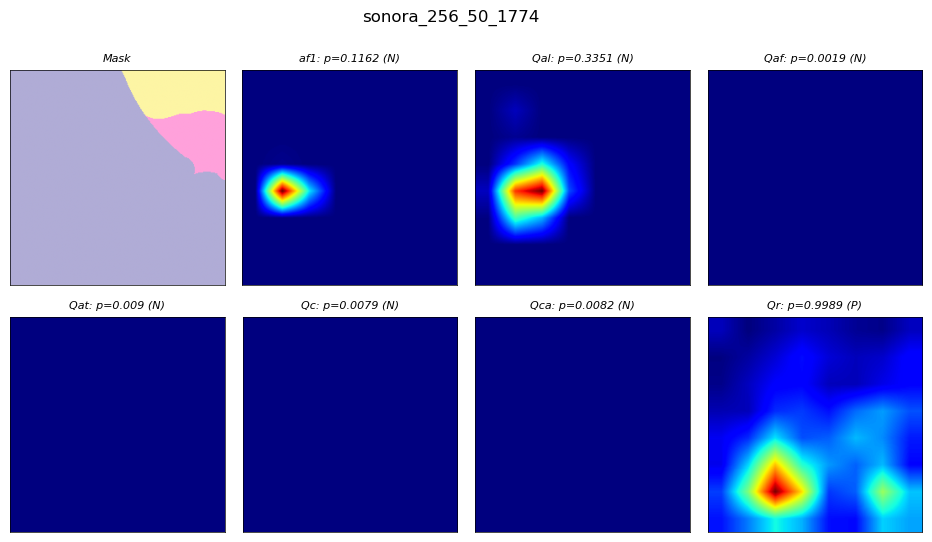

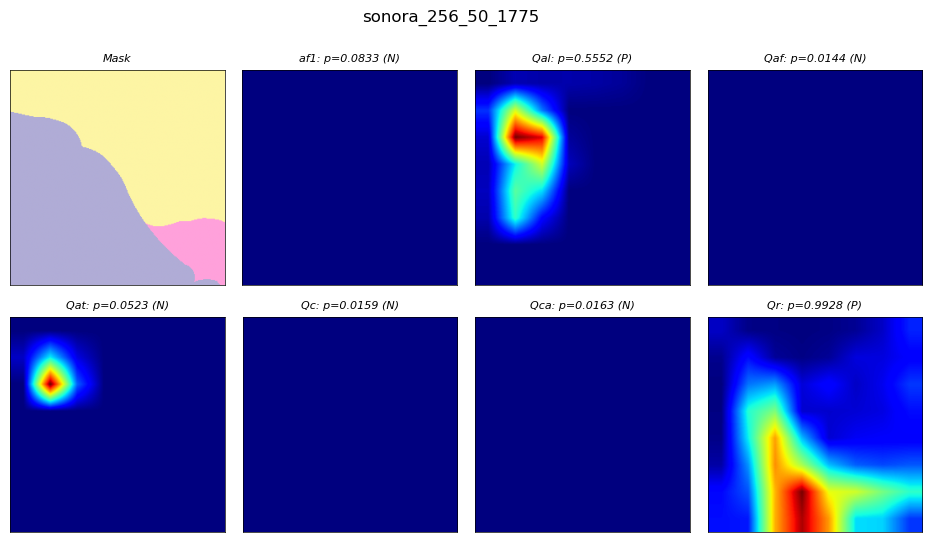

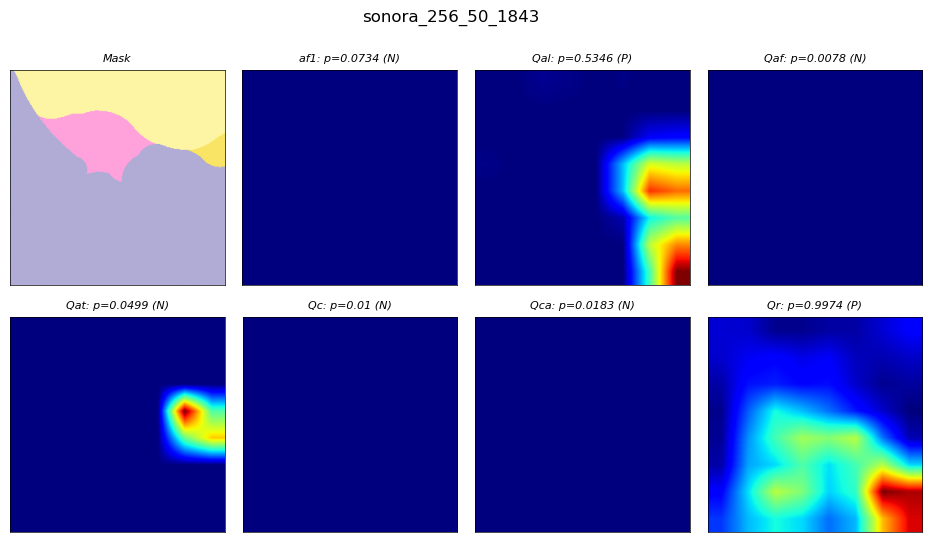

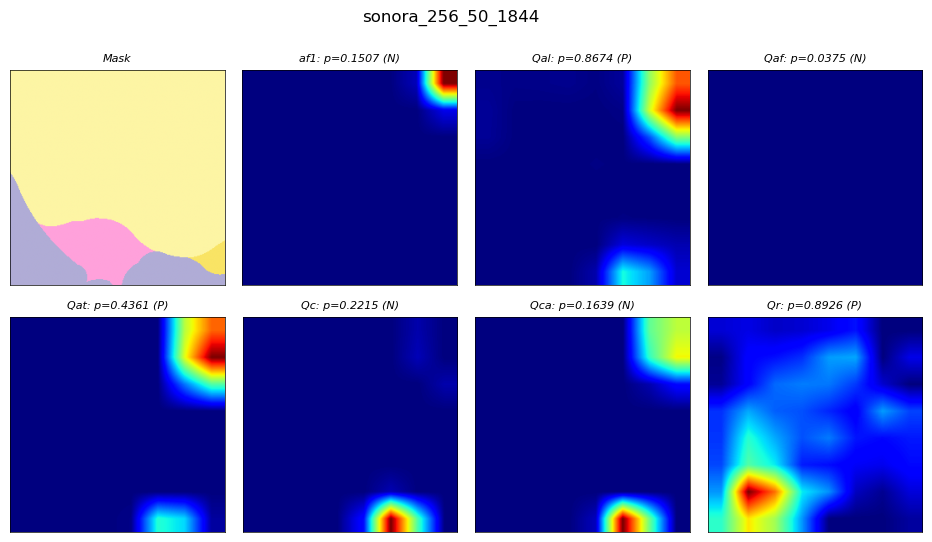

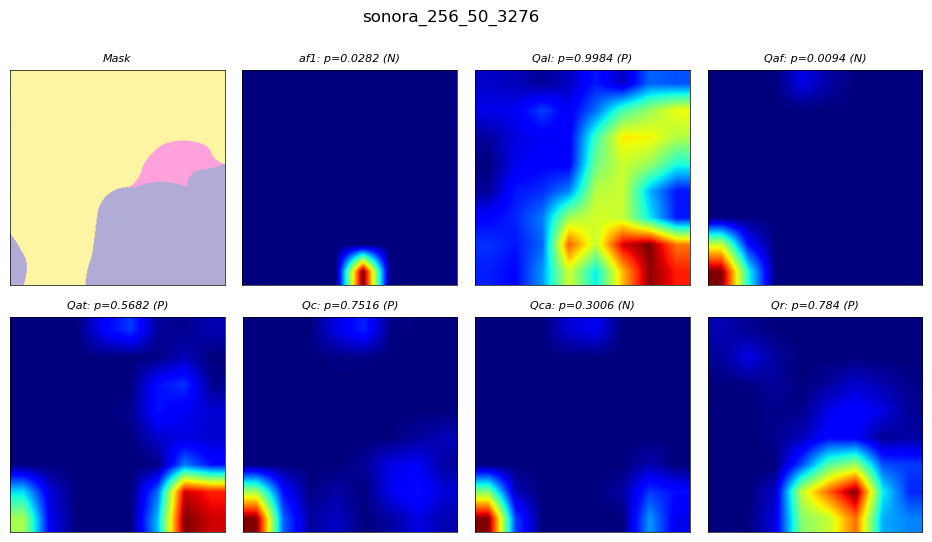

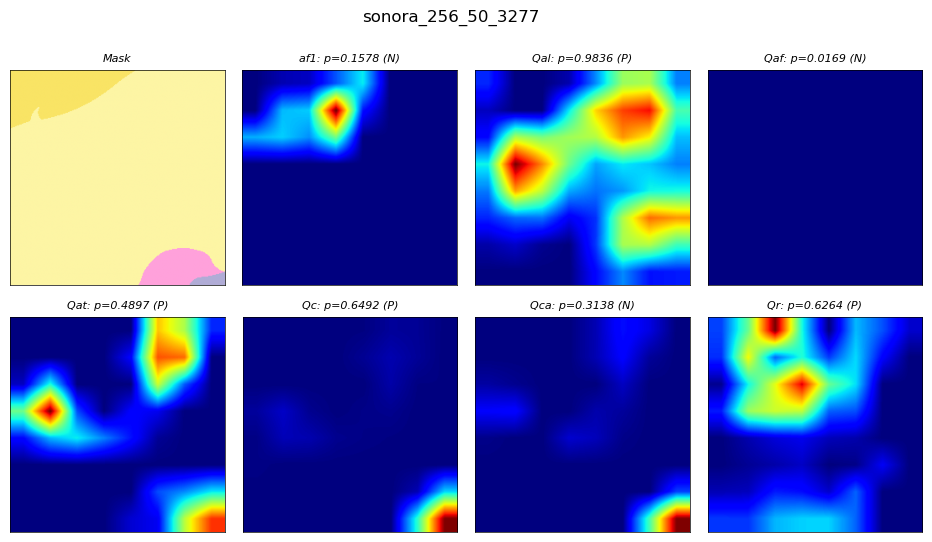

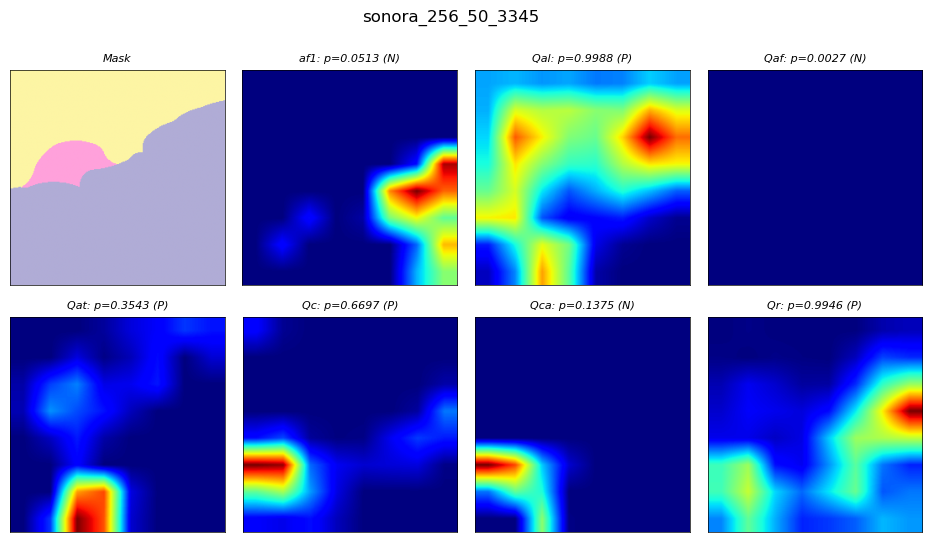

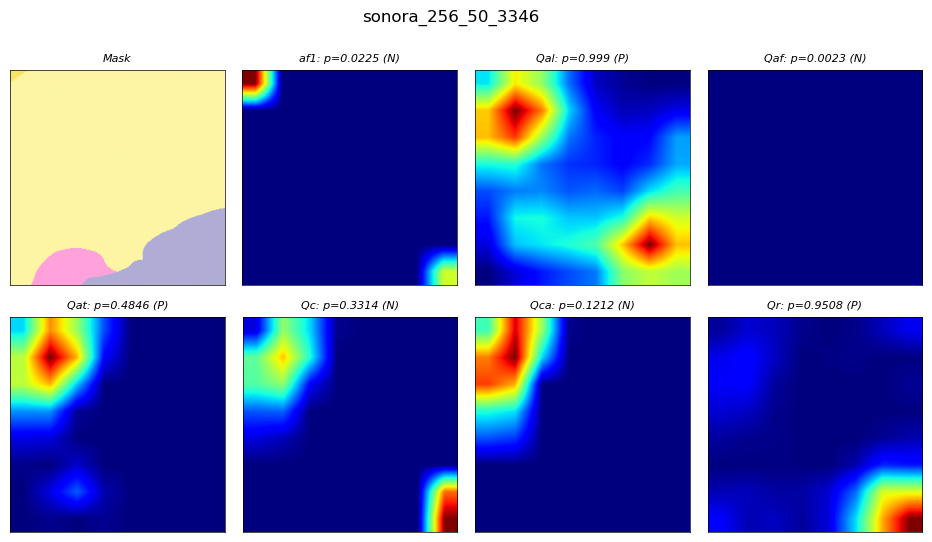

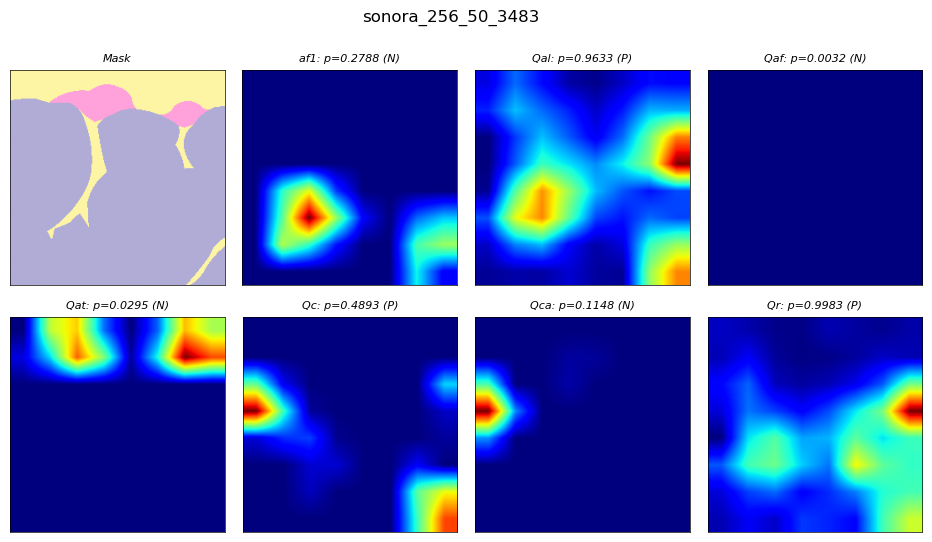

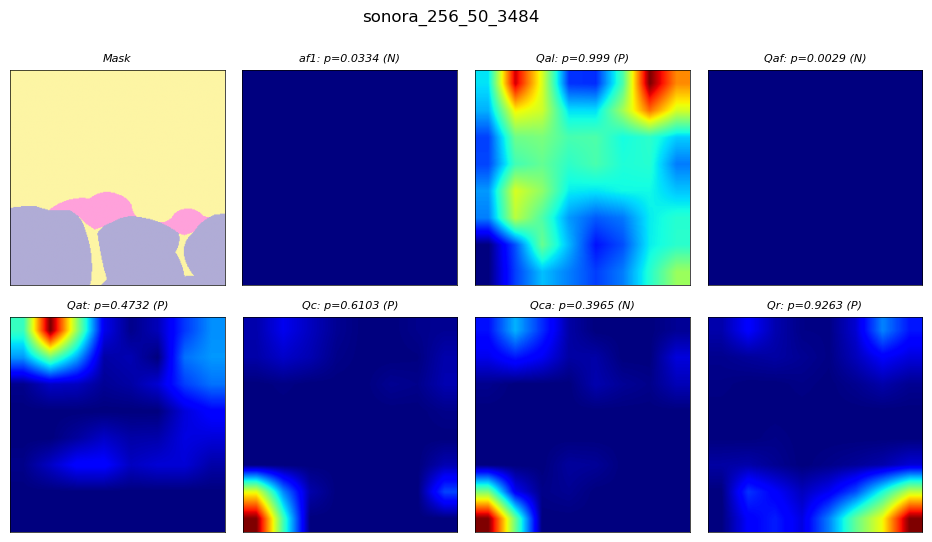

In [83]:
# Cross-domain...

inference_dir = r"E:\GitHub\earthscape\experiments\sgmap-net\classification\single\sgmap-net_s-10_20260802_183004\inference\20260807_155200"


mask_colors = [SG_COLORS[key] for key in SG_MAPPING.keys()]
mask_cmap = ListedColormap(mask_colors)

for path in glob.glob(f"{inference_dir}/gradcams/*.npy"):
    patch_id = os.path.basename(path)
    patch_id = os.path.splitext(patch_id)[0]

    cams = np.load(path)


    probs = pd.read_csv(os.path.join(inference_dir, 'predictions.csv'))
    probs = probs.loc[probs['patch_id'] == patch_id]


    with open(os.path.join(inference_dir, "config.yml")) as f:
        config = yaml.safe_load(f)
    thresholds = config['eval']['thresholds']


    fig, ax = plt.subplots(ncols=4, nrows=2, figsize=(12,6))
    ax = ax.ravel()
    plt.subplots_adjust(hspace=0.15, wspace=0)


    with rasterio.open(f'../data/sonora/patches/{patch_id}_mask.tif') as src:
        data = src.read(1)
        ax[0].imshow(data, vmin=1, vmax=7, cmap=mask_cmap)
        ax[0].set_title('Mask', fontsize=8, style='italic')

    for idx, map_unit in enumerate(SG_MAPPING.keys(), start=1):
        ax[idx].imshow(cams[idx-1], cmap="jet", vmin=0, vmax=1)
        pred = 'P' if probs[map_unit].item() > thresholds[idx-1] else "N"
        title = f"{map_unit}: p={round(probs[map_unit].item(), 4)} ({pred})"
        ax[idx].set_title(title, fontsize=8, style='italic')

    for a in ax:
        a.set_xticks([])
        a.set_yticks([])
        for spine in a.spines.values():
            spine.set_visible(True)
            spine.set_color("k")
            spine.set_linewidth(0.5)

    plt.suptitle(patch_id)
    plt.show()